In [2]:
# Import Libraries

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Fetch Stock Data

In [4]:
# Define stocks to analyze
stocks = {
    'TCS': 'TCS.NS',
    'Infosys': 'INFY.NS',
    'Reliance': 'RELIANCE.NS',
    'Wipro': 'WIPRO.NS',
    'HDFC Bank': 'HDFCBANK.NS'
}

# Fetch 1 year of data for all stocks
stock_data = {}

for name, symbol in stocks.items():
    stock_data[name] = yf.download(symbol, 
                                    start='2024-01-01', 
                                    end='2025-01-01',
                                    progress=False)
    print(f"{name} — {len(stock_data[name])} days of data fetched!")

print("\nAll stocks fetched successfully!")


TCS — 246 days of data fetched!
Infosys — 246 days of data fetched!
Reliance — 246 days of data fetched!
Wipro — 246 days of data fetched!
HDFC Bank — 246 days of data fetched!

All stocks fetched successfully!


In [5]:
# Check what data we have for TCS
print("TCS Data Sample:")
print(stock_data['TCS'].head())

print("\nColumns available:")
print(stock_data['TCS'].columns.tolist())

print("\nData shape:")
print(stock_data['TCS'].shape)

TCS Data Sample:
Price             Close         High          Low         Open   Volume
Ticker           TCS.NS       TCS.NS       TCS.NS       TCS.NS   TCS.NS
Date                                                                   
2024-01-01  3501.880859  3521.085017  3466.872069  3482.492749   825907
2024-01-02  3476.244385  3501.880811  3461.588557  3501.880811  1344068
2024-01-03  3392.214355  3465.815412  3387.895742  3461.358834  1803075
2024-01-04  3369.288818  3417.253449  3354.770730  3401.403054  3598144
2024-01-05  3434.619873  3443.670768  3376.685707  3376.823447  1963127

Columns available:
[('Close', 'TCS.NS'), ('High', 'TCS.NS'), ('Low', 'TCS.NS'), ('Open', 'TCS.NS'), ('Volume', 'TCS.NS')]

Data shape:
(246, 5)


In [6]:
# Create combined closing price dataframe
closing_prices = pd.DataFrame()

for name, data in stock_data.items():
    closing_prices[name] = data['Close'].squeeze()

closing_prices.index = stock_data['TCS'].index

print("Combined Closing Prices:")
print(closing_prices.head())

Combined Closing Prices:
                    TCS      Infosys     Reliance       Wipro   HDFC Bank
Date                                                                     
2024-01-01  3501.880859  1429.635986  1279.692871  223.164429  812.994568
2024-01-02  3476.244385  1414.015747  1290.290039  219.446198  813.473328
2024-01-03  3392.214355  1373.099365  1276.259277  213.225739  800.929626
2024-01-04  3369.288818  1394.018433  1282.854736  211.588776  809.523499
2024-01-05  3434.619873  1412.311035  1288.313843  213.553131  805.382080


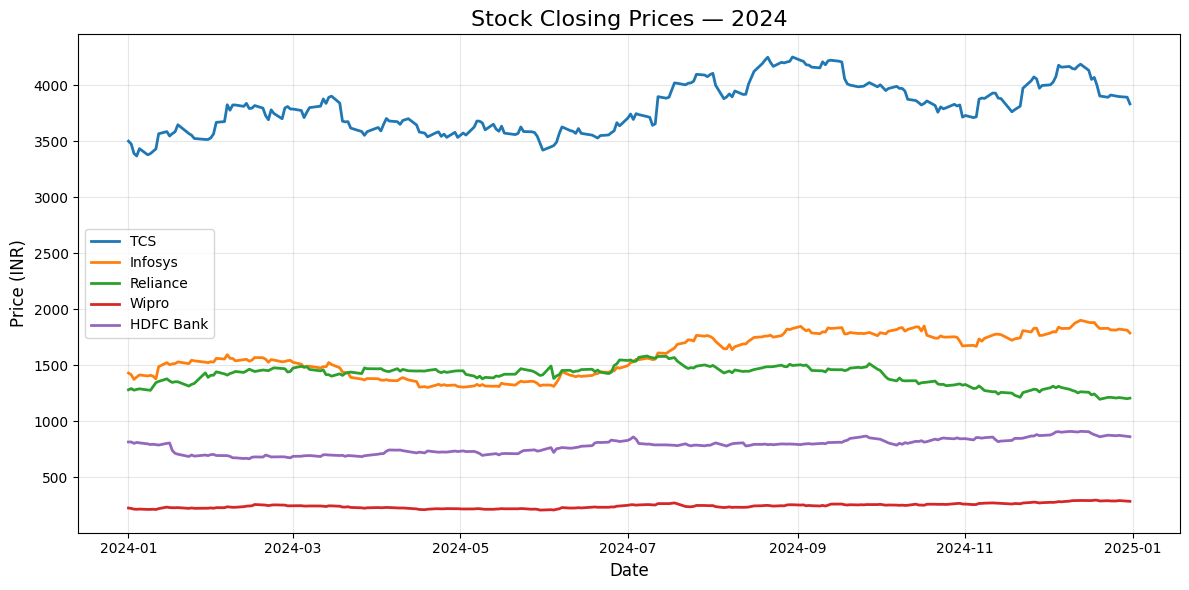

In [7]:
# Plot closing prices of all stocks
plt.figure(figsize=(12, 6))

for name in closing_prices.columns:
    plt.plot(closing_prices.index, closing_prices[name], label=name, linewidth=2)

plt.title('Stock Closing Prices — 2024', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Calculate percentage returns
pct_returns = closing_prices.pct_change() * 100

# Calculate cumulative returns
cumulative_returns = (1 + closing_prices.pct_change()).cumprod() - 1
cumulative_returns = cumulative_returns * 100

print("Daily Percentage Returns (first 5 days):")
print(pct_returns.head())

print("\nCumulative Returns (first 5 days):")
print(cumulative_returns.head())

Daily Percentage Returns (first 5 days):
                 TCS   Infosys  Reliance     Wipro  HDFC Bank
Date                                                         
2024-01-01       NaN       NaN       NaN       NaN        NaN
2024-01-02 -0.732077 -1.092603  0.828102 -1.666140   0.058888
2024-01-03 -2.417265 -2.893630 -1.087411 -2.834617  -1.541993
2024-01-04 -0.675828  1.523493  0.516780 -0.767714   1.072987
2024-01-05  1.939016  1.312221  0.425544  0.928384  -0.511587

Cumulative Returns (first 5 days):
                 TCS   Infosys  Reliance     Wipro  HDFC Bank
Date                                                         
2024-01-01       NaN       NaN       NaN       NaN        NaN
2024-01-02 -0.732077 -1.092603  0.828102 -1.666140   0.058888
2024-01-03 -3.131646 -3.954617 -0.268314 -4.453528  -1.484013
2024-01-04 -3.786309 -2.491372  0.247080 -5.187051  -0.426949
2024-01-05 -1.920710 -1.211844  0.673675 -4.306823  -0.936352


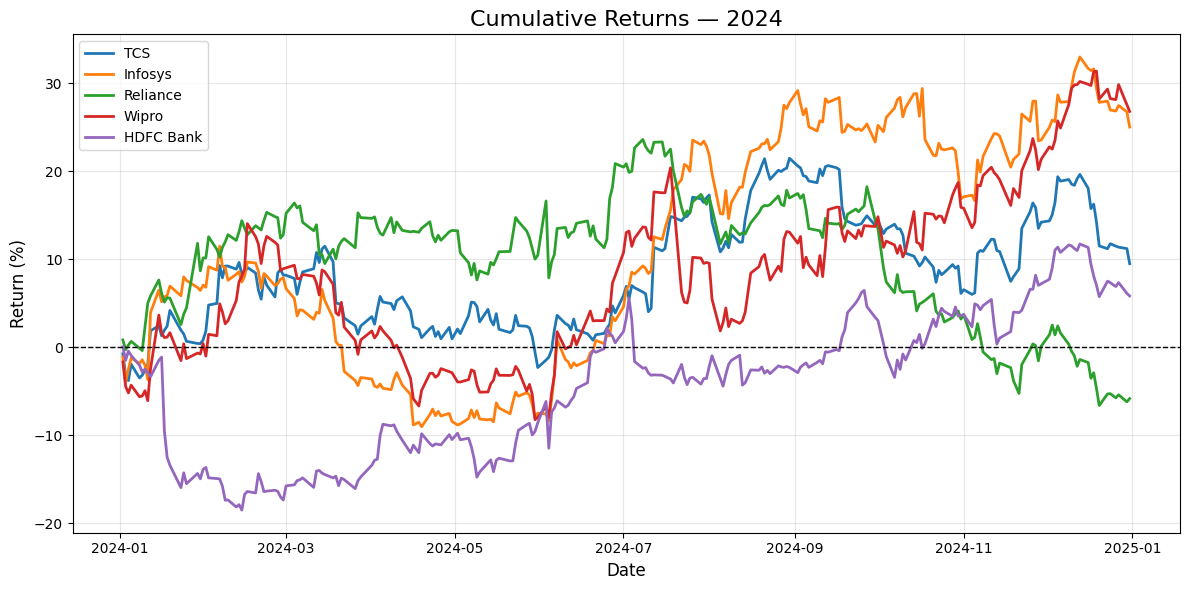

In [9]:
# Plot cumulative returns
plt.figure(figsize=(12, 6))

for name in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, 
             cumulative_returns[name], 
             label=name, linewidth=2)

plt.title('Cumulative Returns — 2024', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Return (%)', fontsize=12)
plt.legend(fontsize=10)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Moving Average

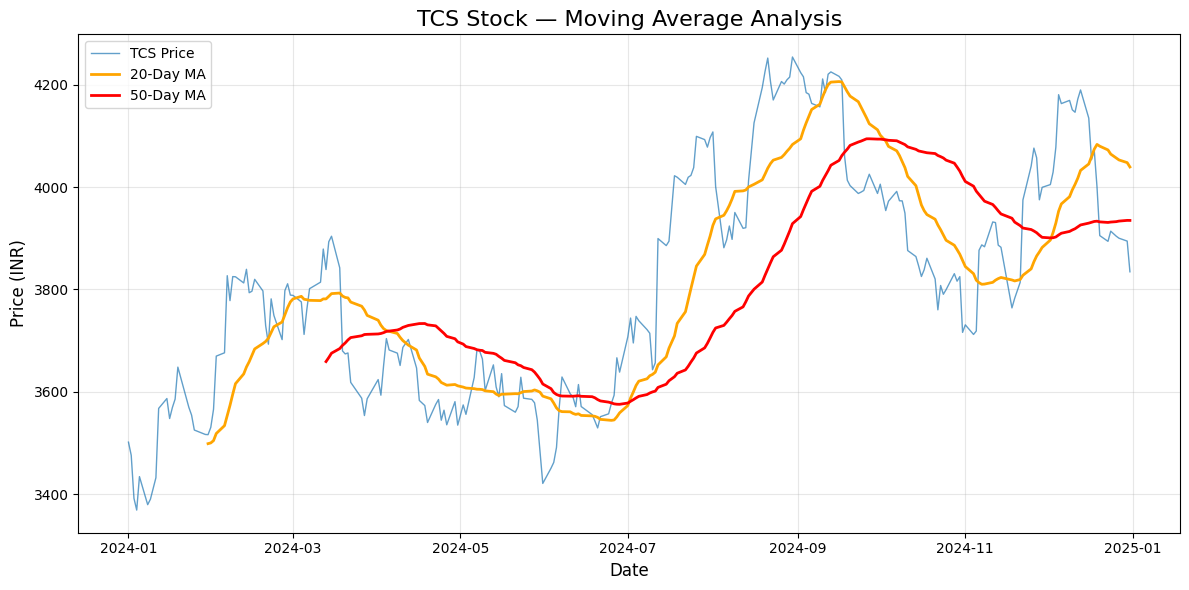

In [11]:
# Calculate 20-day and 50-day moving average for TCS
tcs_data = closing_prices['TCS']

ma_20 = tcs_data.rolling(window=20).mean()
ma_50 = tcs_data.rolling(window=50).mean()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(tcs_data.index, tcs_data, label='TCS Price', linewidth=1, alpha=0.7)
plt.plot(ma_20.index, ma_20, label='20-Day MA', linewidth=2, color='orange')
plt.plot(ma_50.index, ma_50, label='50-Day MA', linewidth=2, color='red')

plt.title('TCS Stock — Moving Average Analysis', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
#  Volatility Analysis

In [13]:
# Calculate volatility (standard deviation of daily returns)
volatility = pct_returns.std()

print("Volatility of each stock (Standard Deviation):")
print(volatility.sort_values(ascending=False))

Volatility of each stock (Standard Deviation):
Wipro        1.762672
Reliance     1.445498
Infosys      1.443543
HDFC Bank    1.411415
TCS          1.334760
dtype: float64


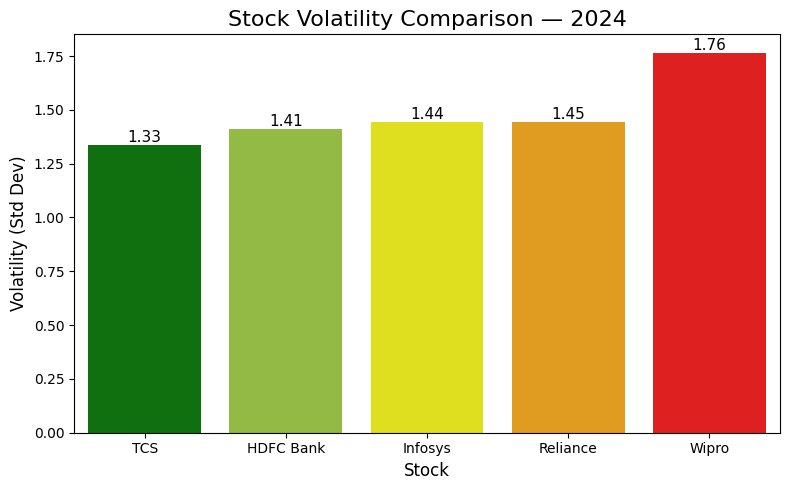

In [14]:
# Plot volatility
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=volatility.sort_values().index, 
                 y=volatility.sort_values().values,
                 hue=volatility.sort_values().index,
                 palette=['green', 'yellowgreen', 'yellow', 'orange', 'red'],
                 legend=False)
plt.title('Stock Volatility Comparison — 2024', fontsize=16)
plt.xlabel('Stock', fontsize=12)
plt.ylabel('Volatility (Std Dev)', fontsize=12)

# Add data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

In [17]:
# Export all stock data to CSV
import pandas as pd

# Add stock name column and combine all stocks
all_stocks = []

for name, data in stock_data.items():
    temp = data.copy()
    temp.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
    temp['Stock'] = name
    temp.reset_index(inplace=True)
    all_stocks.append(temp)

# Combine all stocks into one dataframe
combined_df = pd.concat(all_stocks, ignore_index=True)

# Save to CSV
combined_df.to_csv('stock_data_2024.csv', index=False)

print("CSV saved successfully!")
print(f"Total rows: {len(combined_df)}")

CSV saved successfully!
Total rows: 1230


In [20]:
combined_df.head()

,Date,Close,High,Low,Open,Volume,Stock
984,2024-01-01,812.994568,818.284969,810.074100,816.776840,14239686,HDFC Bank
985,2024-01-02,813.473328,815.244801,808.494137,813.329733,29242092,HDFC Bank
986,2024-01-03,800.929626,816.154388,799.038461,814.861740,28389762,HDFC Bank
987,2024-01-04,809.523499,811.486432,799.876328,803.371352,26734056,HDFC Bank
988,2024-01-05,805.382080,816.250129,798.631475,807.752013,31889470,HDFC Bank


In [21]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1230 entries, 984 to 983
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1230 non-null   datetime64[ns]
 1   Close   1230 non-null   float64       
 2   High    1230 non-null   float64       
 3   Low     1230 non-null   float64       
 4   Open    1230 non-null   float64       
 5   Volume  1230 non-null   int64         
 6   Stock   1230 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 76.9+ KB


In [22]:
combined_df.describe()

,Date,Close,High,Low,Open,Volume
count,1230,1230.000000,1230.000000,1230.000000,1230.000000,1.230000e+03
mean,2024-07-02 01:39:30.731707392,1566.357777,1581.466933,1552.269056,1566.499598,1.619781e+07
min,2024-01-01 00:00:00,204.798599,207.235849,195.448044,205.079824,1.548950e+05
25%,2024-04-02 00:00:00,716.654984,725.460828,708.707119,716.403309,4.645296e+06
50%,2024-07-03 12:00:00,1377.541016,1392.290551,1367.558278,1381.208514,9.615082e+06
75%,2024-10-01 00:00:00,1776.543274,1788.725767,1757.377299,1773.480561,2.010920e+07
max,2024-12-31 00:00:00,4253.906738,4289.871692,4214.905459,4274.691352,4.453421e+08
std,NaN,1227.549006,1239.620468,1216.635143,1227.500340,2.453460e+07


In [23]:
combined_df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Stock     0
dtype: int64

In [19]:
combined_df.drop_duplicates(inplace=True)
combined_df.dropna(inplace=True)
combined_df['Date'] = pd.to_datetime(combined_df['Date'])
combined_df = combined_df.sort_values(['Stock', 'Date'])

In [18]:
import os
print(os.getcwd())

c:\Users\hp\Desktop\stock_data_analysis
